In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE, Isomap
from scipy.io import arff

sns.set(style="whitegrid", context="notebook")

## Part-A : Preprocessing and Initial Setup

### Data Loading

In [2]:
data = arff.loadarff(r"data/yeast-train.arff")
df = pd.DataFrame(data[0])

In [3]:
df.head()

,Att1,Att2,Att3,Att4,Att5,Att6,Att7,Att8,Att9,Att10,...,Class5,Class6,Class7,Class8,Class9,Class10,Class11,Class12,Class13,Class14
0,0.093700,0.139771,0.062774,0.007698,0.083873,-0.119156,0.073305,0.005510,0.027523,0.043477,...,b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0'
1,-0.022711,-0.050504,-0.035691,-0.065434,-0.084316,-0.378560,0.038212,0.085770,0.182613,-0.055544,...,b'0',b'0',b'1',b'1',b'0',b'0',b'0',b'1',b'1',b'0'
2,-0.090407,0.021198,0.208712,0.102752,0.119315,0.041729,-0.021728,0.019603,-0.063853,-0.053756,...,b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'1',b'1',b'0'
3,-0.085235,0.009540,-0.013228,0.094063,-0.013592,-0.030719,-0.116062,-0.131674,-0.165448,-0.123053,...,b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'1',b'1',b'1'
4,-0.088765,-0.026743,0.002075,-0.043819,-0.005465,0.004306,-0.055865,-0.071484,-0.159025,-0.111348,...,b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0',b'0'


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Columns: 117 entries, Att1 to Class14
dtypes: float64(103), object(14)
memory usage: 1.3+ MB


**We need to convert the last 14 columns to integer**

In [5]:
for col in df.columns[-14:]:
    df[col] = df[col].apply(lambda x: int(x))

In [6]:
# get the labels
df['label'] = df.iloc[:,-14:].apply(lambda row: tuple(col for col in df.iloc[:,-14:].columns if row[col] == 1), axis=1)

In [7]:
df.head()

,Att1,Att2,Att3,Att4,Att5,Att6,Att7,Att8,Att9,Att10,...,Class6,Class7,Class8,Class9,Class10,Class11,Class12,Class13,Class14,label
0,0.093700,0.139771,0.062774,0.007698,0.083873,-0.119156,0.073305,0.005510,0.027523,0.043477,...,0,0,0,0,0,0,0,0,0,"(Class3, Class4)"
1,-0.022711,-0.050504,-0.035691,-0.065434,-0.084316,-0.378560,0.038212,0.085770,0.182613,-0.055544,...,0,1,1,0,0,0,1,1,0,"(Class7, Class8, Class12, Class13)"
2,-0.090407,0.021198,0.208712,0.102752,0.119315,0.041729,-0.021728,0.019603,-0.063853,-0.053756,...,0,0,0,0,0,0,1,1,0,"(Class2, Class3, Class12, Class13)"
3,-0.085235,0.009540,-0.013228,0.094063,-0.013592,-0.030719,-0.116062,-0.131674,-0.165448,-0.123053,...,0,0,0,0,0,0,1,1,1,"(Class3, Class4, Class12, Class13, Class14)"
4,-0.088765,-0.026743,0.002075,-0.043819,-0.005465,0.004306,-0.055865,-0.071484,-0.159025,-0.111348,...,0,0,0,0,0,0,0,0,0,"(Class1, Class2)"


### Dimensionality Check

In [8]:
print(f"Initial # of features : {df.shape[1]-14}")
print(f"Initial # datapoints : {df.shape[0]}")

Initial # of features : 104
Initial # datapoints : 1500


### Label Selection for Visualization

In [9]:
# get the frequency of each single class labels
class_freq = df[df["label"].map(len) == 1]['label'].value_counts().sort_values(ascending=False)
print(class_freq)

label
(Class1,)    24
Name: count, dtype: int64


**There is only single class for which the data point is a single class, therefore in top 2 frequent single-label classes we will have only `Class1`**

In [10]:
top_single = class_freq.head(2).index.tolist()

In [11]:
# frequency of multi-label combinations
multi_class_freq = df['label'].value_counts().sort_values(ascending=False)
print(f"Top 7 multi-label combinations")
print(multi_class_freq[:7])

Top 7 multi-label combinations
label
(Class3, Class4, Class12, Class13)    145
(Class4, Class5, Class12, Class13)    145
(Class1, Class2, Class12, Class13)    105
(Class1, Class2)                       80
(Class2, Class3, Class12, Class13)     77
(Class5, Class6, Class12, Class13)     65
(Class7, Class8, Class12, Class13)     44
Name: count, dtype: int64


In [12]:
top_mult = multi_class_freq.head(1).index.tolist()

In [13]:
# function to assign group to each multiclass labels
def assign_group(labels):
    if labels in top_single:
        return labels[0]
    elif labels in top_mult:
        return "+".join(labels)
    else:
        return "Other"

In [14]:
df["visualization_target"] = df["label"].apply(assign_group)
df.head()

,Att1,Att2,Att3,Att4,Att5,Att6,Att7,Att8,Att9,Att10,...,Class7,Class8,Class9,Class10,Class11,Class12,Class13,Class14,label,visualization_target
0,0.093700,0.139771,0.062774,0.007698,0.083873,-0.119156,0.073305,0.005510,0.027523,0.043477,...,0,0,0,0,0,0,0,0,"(Class3, Class4)",Other
1,-0.022711,-0.050504,-0.035691,-0.065434,-0.084316,-0.378560,0.038212,0.085770,0.182613,-0.055544,...,1,1,0,0,0,1,1,0,"(Class7, Class8, Class12, Class13)",Other
2,-0.090407,0.021198,0.208712,0.102752,0.119315,0.041729,-0.021728,0.019603,-0.063853,-0.053756,...,0,0,0,0,0,1,1,0,"(Class2, Class3, Class12, Class13)",Other
3,-0.085235,0.009540,-0.013228,0.094063,-0.013592,-0.030719,-0.116062,-0.131674,-0.165448,-0.123053,...,0,0,0,0,0,1,1,1,"(Class3, Class4, Class12, Class13, Class14)",Other
4,-0.088765,-0.026743,0.002075,-0.043819,-0.005465,0.004306,-0.055865,-0.071484,-0.159025,-0.111348,...,0,0,0,0,0,0,0,0,"(Class1, Class2)",Other


In [15]:
# standardizing the data
X, y = df.iloc[:,:-16], df['visualization_target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Why Scaling before Distance-based Dimension Reduction
- **Equal Feature Influence:** Scaling ensures all features contribute equally to distance calculations; unscaled features with large ranges dominate the distances.  
- **Preserves True Geometry:** Methods like PCA, t-SNE, and UMAP rely on Euclidean or similar metrics; unscaled data distorts the geometric relationships between points.  
- **Improves Numerical Stability:** Standardized features prevent very large or very small values from causing computational instability or precision errors.  
- **Meaningful Component Directions:** In PCA, unscaled features bias variance toward high-magnitude dimensions, skewing principal components.  
- **Fair Neighborhood Relationships:** For t-SNE and UMAP, scaling maintains genuine neighbor structures, leading to more faithful low-dimensional embeddings.

## Part-B: t-SNE and Veracity Inspection

### t-SNE Implementation and Visualization

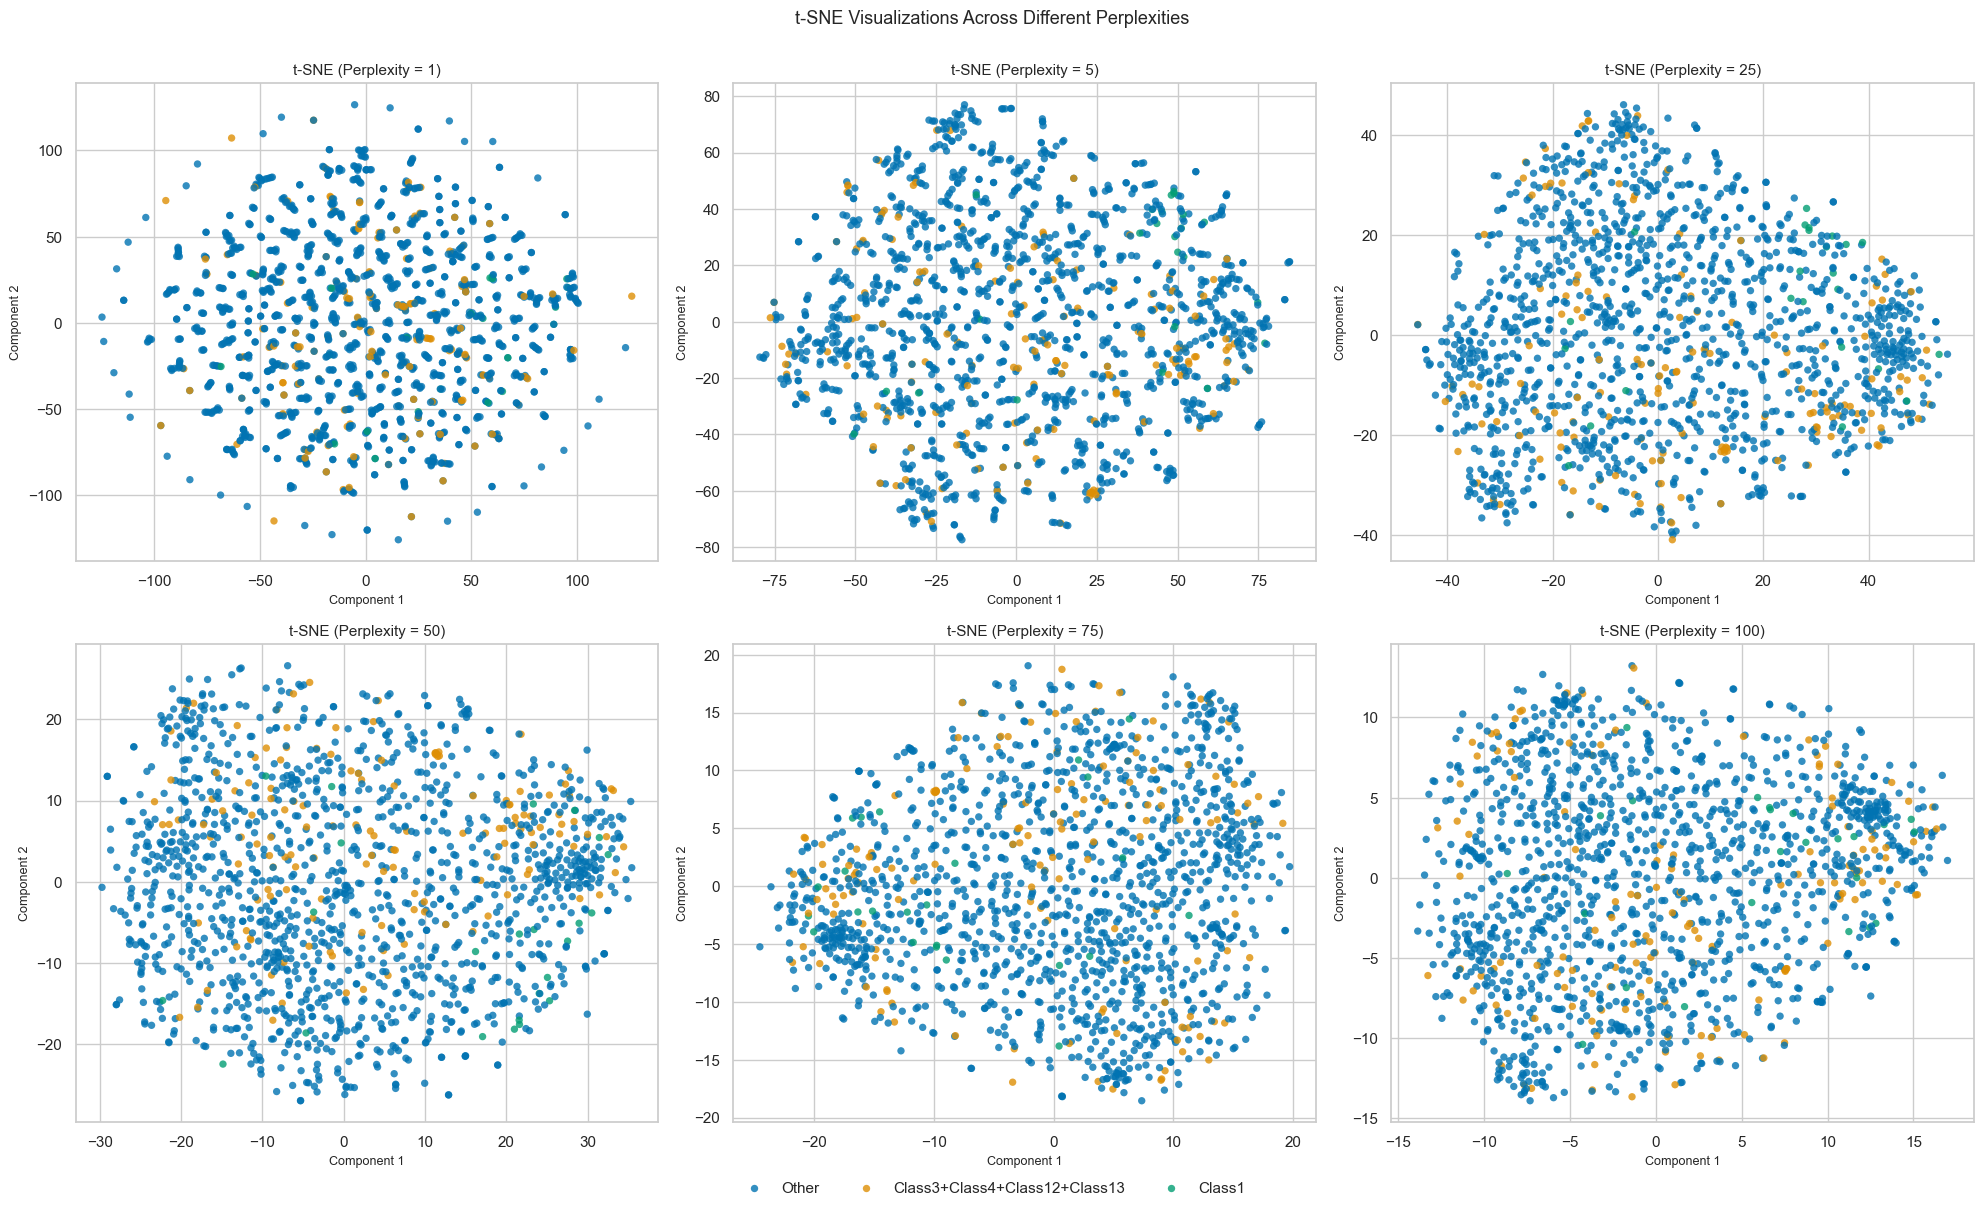

In [16]:
perplexities = [1, 5, 25, 50, 75, 100]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca', learning_rate='auto')
    X_embedded = tsne.fit_transform(X_scaled)

    scatter = sns.scatterplot(
        x=X_embedded[:, 0], 
        y=X_embedded[:, 1],
        hue=y,
        palette="colorblind",
        alpha=0.8,
        s=28,
        ax=axes[i],
        edgecolor="none"
    )

    axes[i].set_title(f"t-SNE (Perplexity = {perp})", fontsize=11)
    axes[i].set_xlabel("Component 1", fontsize=9)
    axes[i].set_ylabel("Component 2", fontsize=9)
    axes[i].legend([], [], frameon=False)

handles, labels = scatter.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=min(len(set(y)), 6), frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.suptitle("t-SNE Visualizations Across Different Perplexities", fontsize=13)
plt.show()

### t-SNE Analysis (Best Perplexity = 25)

| Category                     | Observation & Interpretation                                                                 | Likely Causes / Implications |
|-------------------------------|---------------------------------------------------------------------------------------------|------------------------------|
| **Cluster Separation**        | Smooth, round clusters with clear gaps. Good balance between **local neighborhood** preservation and **global structure**. | – |
| **Noisy / Ambiguous Labels**  | Points $x_i$ of class $c_i$ embedded inside clusters of another class $c_j$ $i \neq j$. | Mislabeling: $y_i \neq \text{true class}$ <br> True overlap in feature space: $x_i \approx x_j$ |
| **Outliers**                  | Points $x_i$ isolated from all clusters or in small detached groups. | Rare conditions, experimental artifacts, or unique feature combinations. |
| **Hard-to-Learn Samples**     | Dense regions where multiple classes overlap: $\{x_i \mid y_i \in \{c_1, c_2, c_3\}\}$ intermixed. | Classifier struggle due to nonlinear/fuzzy boundaries; higher misclassification probability $P(\hat{y}_i \neq y_i)$. |


## Isomap and Manifold Learning

### Isomap Implementation and Visualization

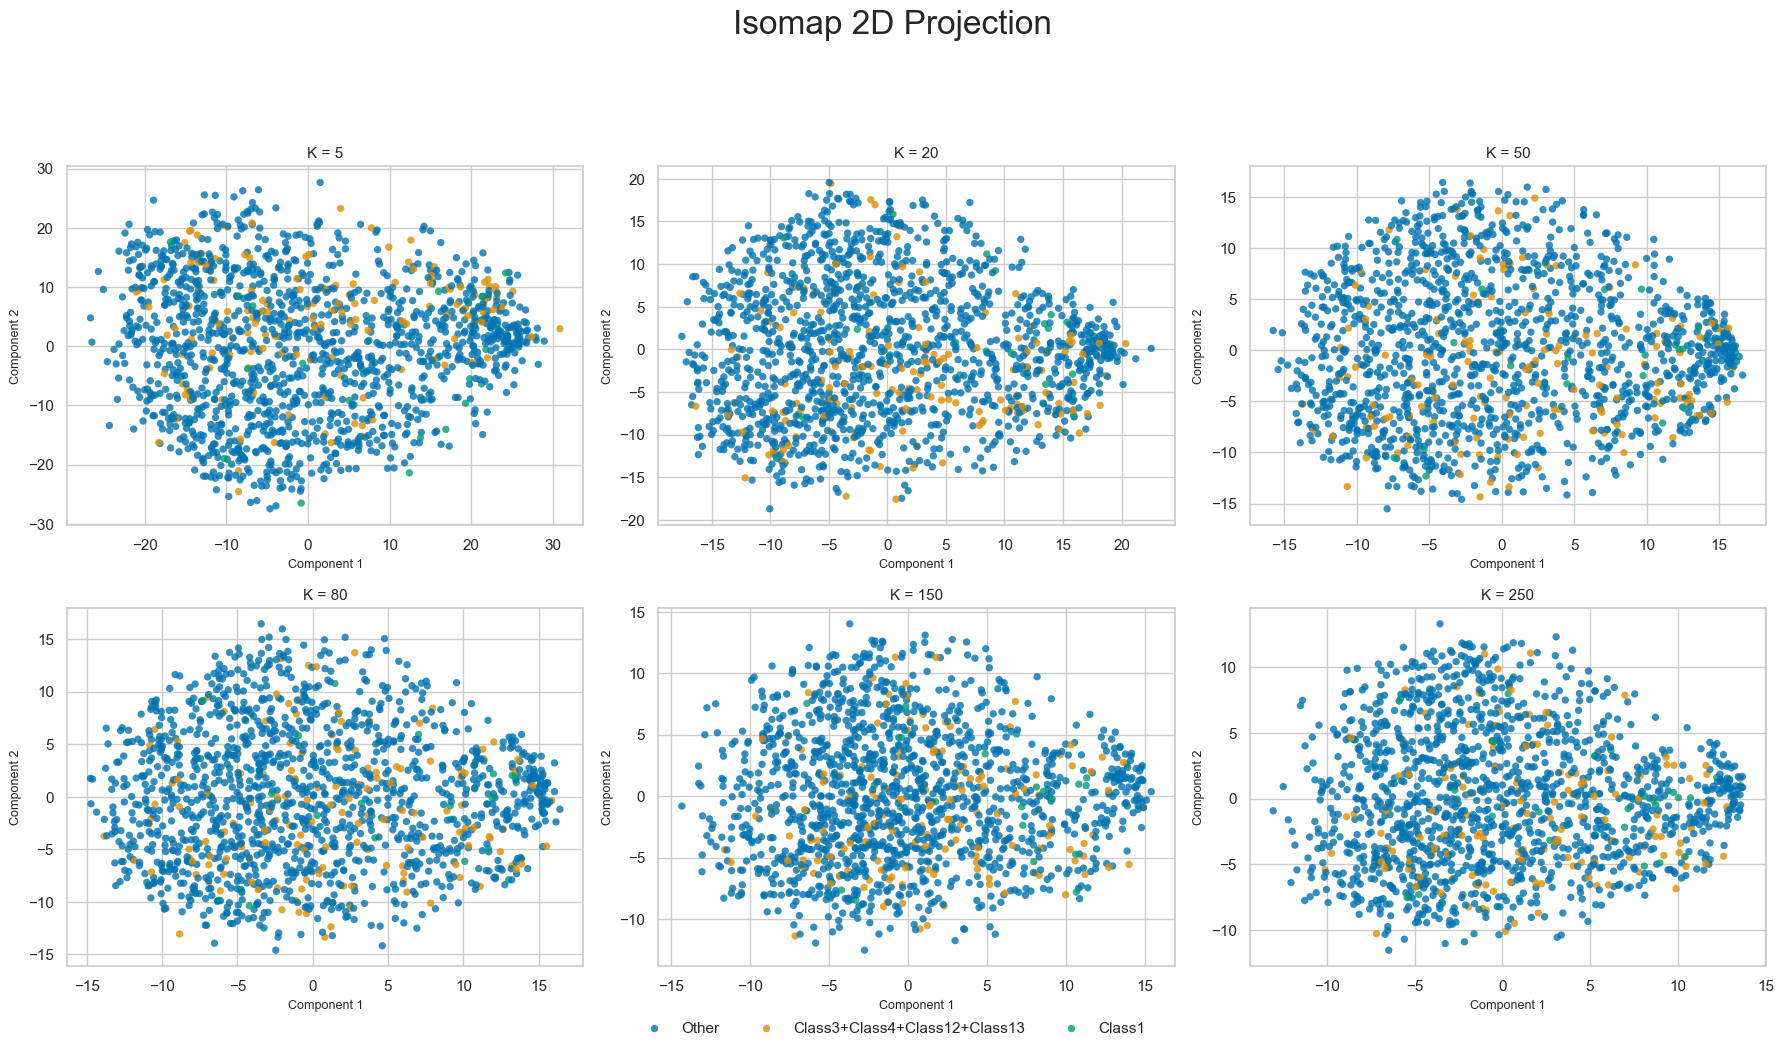

In [17]:
k_neighbours = [5, 20, 50, 80, 150, 250]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
plt.suptitle("Isomap 2D Projection", fontsize=24, y=1.02)

for i, k_n in enumerate(k_neighbours):
    isomap = Isomap(n_components=2, n_neighbors=k_n)
    X_iso = isomap.fit_transform(X_scaled)

    scatter = sns.scatterplot(
        x=X_iso[:, 0],
        y=X_iso[:, 1],
        hue=y,
        palette="colorblind",
        alpha=0.8,
        s=28,
        ax=axes[i],
        edgecolor="none"
    )

    axes[i].set_title(f"K = {k_n}", fontsize=11)
    axes[i].set_xlabel("Component 1", fontsize=9)
    axes[i].set_ylabel("Component 2", fontsize=9)
    axes[i].grid(True)
    axes[i].legend([], [], frameon=False)

handles, labels = scatter.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=min(len(set(y)), 6), frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Isomap Analysis (Best k_neighbors = 20)

| Category                     | Observation & Interpretation                                                                 | Likely Causes / Implications |
|-------------------------------|---------------------------------------------------------------------------------------------|------------------------------|
| **Cluster Separation**        | Smooth, continuous embedding; clusters less distinct but well-separated globally. Global geometry of manifold preserved: $\|x_i - x_j\|_G \approx \|z_i - z_j\|_2$, where $\| \cdot \|_G$ = geodesic distance on the graph. | – |
| **Disconnected Graphs**       | Not observed for $k=20$; neighbors graph fully connected. | Avoids warnings about disconnected components; ensures geodesic distances are meaningful. |
| **Global vs Local Structure** | Preserves global distances along the manifold; local neighborhoods partially preserved ($x_i$ close to neighbors $x_j$ in geodesic space). | Good for manifold unfolding; less precise for local clusters. |
| **Hard-to-Learn Samples**     | Dense overlapping regions remain ($x_i$ from different classes $c_1, c_2, c_3$ intermixed). | Non-linear decision boundaries needed: $P(\hat{y}_i \neq y_i)$ higher for linear models. |
| **Manifold Insight**          | Embedding shows curved, elongated structure → data lies on a non-linear manifold. | Linear methods (PCA, MDS) insufficient; non-linear classifiers (kernel SVM, tree ensembles, deep nets) preferred. |

### Comparison with t-SNE

| Aspect                        | Isomap                                | t-SNE                                      |
|--------------------------------|---------------------------------------|-------------------------------------------|
| Goal                           | Preserve **global manifold geometry** | Preserve **local neighborhoods**          |
| Method                         | 1. Build k-NN graph <br> 2. Compute geodesic distances <br> 3. Classical MDS | 1. Pairwise similarities <br> 2. Minimize KL divergence between high- and low-dim similarities |
| Preserves                      | Global distances along the manifold   | Local neighbors; global distances may distort |
| Visualization effect            | Continuous, curved embedding          | Tight, compact clusters                    |
| Key parameter                   | `n_neighbors` (k)                     | `perplexity`                               |

**Interpretation:**  
- **Isomap**: Good for global relationships ($\|x_i - x_j\|_G$ meaningful).  
- **t-SNE**: Good for local clusters ($x_i$ grouped tightly with nearest neighbors).  
- **Implication for classification**: Curved manifolds → linear classifiers struggle; non-linear models needed.  
- **Dataset insight**: Overlapping embeddings indicate hard-to-separate samples, confirming need for flexible models.
